- [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/c4dynamics/c4dynamics/blob/main/docs/source/programs/ekf_estimation/quad_ekf.ipynb) ← Click to open in Google Colab
- To download this notebook, click the download icon in the toolbar above and select the .ipynb format.  
- For any questions or comments, please open an issue on the [c4dynamics issues page](https://github.com/c4dynamics/c4dynamics/issues).  

# Quadcopter EKF - State Estimation for Figure-8 Trajectory Tracking

*An estimation-control companion to the Cascade-PID example.*

<div style="margin-top: 30px;"></div>

This notebook extends the <a href="https://c4dynamics.github.io/c4dynamics/programs/pid_cascade/quadcopter_pid.html" target="_blank">Quadcopter Cascade-PID figure-8 example</a> so that the quadcopter no longer has access to its true state. Instead it carries an
**Extended Kalman Filter** ($EKF$) that reconstructs the full state vector from
**noisy GPS and IMU measurements**, and the cascade controller closes the loop on
that *estimate*. The result is a complete, realistic **estimation-control pipeline**.

## Author

This notebook was developed by Usama Khan ([\@usama-k-mech](https://github.com/usama-k-mech)) as part of the c4dynamics project, under the guidance of the *c4dynamics maintainers*.

## Goal

1. Build an $EKF$ that predicts with the same dynamics the truth model uses, corrects with noisy $GPS$, $IMU$, and magnetometer, and feed its estimate to the
cascade controller in place of truth. 

2. Investigate whether a faster $IMU$ update rate slows the position drift during a $GPS$ dropout.


## Overview

![The EKF receives the same control inputs that drive the plant to predict the system state and incorporates GPS, IMU, and magnetometer measurements to correct the prediction. The resulting state estimate replaces the true state in the feedback loop, enabling output-feedback control based solely on sensor information.](architecture.png)

{{< pagebreak >}}

## Table of Contents

1. Setup
2. The Estimation Problem
3. Dynamics
4. Sensors - The Measurements
5. Extended Kalman Filter
6. C4DYNAMICS
7. Simulation
8. Results
9. GPS Dropout Experiment
10. Summary & Conclusions
11. Appendix: Sensor Demos


## 1. Setup

In [20]:
import sys
# On Google Colab, install c4dynamics -- it ships this example's own module too.
# Pin >=2.5.0: this notebook uses the FLU (forward-left-up) body frame and the
# frame='ENU' sensors introduced in that release; older versions simulate the
# vehicle in a different body frame and the EKF diverges.
if 'google.colab' in sys.modules:
    !pip install -q "c4dynamics>=2.5.0"

import c4dynamics as c4d
assert tuple(map(int, c4d.__version__.split('.')[:2])) >= (2, 5), (
    f'this notebook needs c4dynamics >= 2.5.0, found {c4d.__version__}')

from c4dynamics.utils.use_cases import quad_ekf

- The main loop, an $EKF$ layer, and plots generators live in [c4dynamics.utils.use_cases.quad_ekf](https://github.com/c4dynamics/c4dynamics/blob/main/c4dynamics/utils/use_cases/quad_ekf.py).  
- The estimation config block is shown as an editable dictionary in the notebook and is defined canonically in [ekf_config.py](https://github.com/c4dynamics/c4dynamics/blob/main/c4dynamics/utils/use_cases/ekf_config.py).


Core models live in c4dynamics: 
- The plant and cascade-$PID$ controller in [c4dynamics.controllers.quad_pid](https://github.com/c4dynamics/c4dynamics/blob/main/c4dynamics/controllers/quad_pid.py)
- The navigation sensors ($GPS$, $IMU$, magnetometer) in [c4dynamics.sensors.navigation](https://github.com/c4dynamics/c4dynamics/blob/main/c4dynamics/sensors/navigation.py) 

This notebook only configures them and shows the results.

## 2. The Estimation Problem

New to Kalman filtering?
1. [c4dynamics's filters page](https://c4dynamics.github.io/c4dynamics/concepts/filters.html) provides a practical introduction to Kalman filtering, covering the underlying equations, the predict/update algorithm, and their implementation through the framework's kalman and ekf classes before applying them to realistic estimation problems.

2. [Kalman and Bayesian Filters in Python](https://rlabbe.github.io/Kalman-and-Bayesian-Filters-in-Python/) builds the intuition from scratch, in the same notebook-driven style as this example, before diving into the equations below.

---

In the Cascade-$PID$ example the controller read the vehicle's **true** state directly. A real autopilot never sees truth, it only sees noisy sensors. The job of the $EKF$ is to fuse those measurements with a dynamics model into a best estimate $\hat{x}$, which the controller then uses in place of truth.

The $EKF$ algorithm operates as two sequential steps:  
Predict (process model) $\rightarrow$ Update (measurement model).  

**Predict**  
The predict stage needs a process model $f(\mathbf x, \mathbf u)$ — the equations of motion mapping the current state and the commanded rotor speeds to the next state. **Section** $3$ derives exactly this model, the same one that drives the truth vehicle. 

**Update**  
The update (correct) stage needs a measurement model $h(\mathbf x)$ for every sensor feeding the filter, together with its Jacobian $H=\partial h/\partial \mathbf x$ for computing the update. **Section** $4$ introduces the $GPS$, $IMU$, and magnetometer models on these terms, one sensor at a time, before **Section** $5$ assembles $f$, $h$, and $H$ into the full predict/update cycle.


**EKF vs. Strapdown INS**  
It's worth noting that the design of choice here differs from what most real flight controllers like PX4 and ArduPilot do:

- A typical strapdown $INS$-based $EKF$ carries $15+$ state variables and represents attitude using a quaternion rather than Euler angles.
- These systems commonly use an error-state (indirect) $EKF$: rather than estimating the complete navigation state directly, the filter only estimates small errors relative to the state propagated by the inertial mechanism.
- In the predict stage, strapdown integrates the $IMU$ readings — pure kinematics with no vehicle model and no knowledge of commanded inputs.
- In the correct stage, strapdown uses only the aiding sensors — $GPS$, magnetometer, baro, sometimes vision — to bound the drift the $IMU$ mechanization accumulates in the predict stage. 

In contrast, the EKF in this example uses the full nonlinear quadrotor dynamics as its process model. 
The commanded rotor speeds drive the prediction, while the $GPS$, $IMU$, and magnetometer measurements are used as measurement updates.

This architectural difference becomes particularly relevant in Section $9$, where we investigate what happens when GPS is temporarily unavailable and examine the effect of increasing the IMU update rate.

## 3. Dynamics

The quadrotor dynamics is identical to this presented in the [parent example](https://c4dynamics.github.io/c4dynamics/programs/pid_cascade/quadcopter_pid.html).  
This section summarizes the governing equations, which form the process model
used by both the simulation and the Extended Kalman Filter ($EKF$).

The vehicle is modeled as a 12-state quadcopter,
$$
\mathbf{x} =
\begin{bmatrix}
x & y & z &
v_x & v_y & v_z &
\varphi & \theta & \psi &
p & q & r
\end{bmatrix}^T
$$

Where
- $x, y, z$ are the inertial position coordinates of the quad [$m$]
- $v_x, v_y, v_z$ are the inertial velocity coordinates of the quad [$m/s$]
- $\varphi, \theta, \psi$ are three Euler angles representing roll, pitch, and yaw respectively [$rad$]
- $p, q, r$ are the body rates about $x,y,z$ respectively [$rad/s$]

The state evolves according to the non-linear process model

$$
\dot{\mathbf x}=f(\mathbf x,\mathbf u),
$$

where the control input

$$
\mathbf u=
\left[\Omega_1,\Omega_2,\Omega_3,\Omega_4\right]^T
$$

consists of the four rotor speeds.

(The actual outputs of the cascade $PID$ controller $[T, \tau_x, \tau_y, \tau_z]$ are mapped to individual rotor speeds by the inverse of the thrust-torque mixing matrix. See Control Allocation in the [Cascade PID example](https://c4dynamics.github.io/c4dynamics/programs/pid_cascade/quadcopter_pid.html#4.-Cascade-PID-Control))

The translational motion consists of the position kinematics and Newton's second law:

$$
\begin{aligned}
\dot{x} &= v_x \\
\dot{y} &= v_y \\
\dot{z} &= v_z \\
\dot{v}_x &= F_x / m \\
\dot{v}_y &= F_y / m \\
\dot{v}_z &= F_z / m
\end{aligned}
$$

The three force components form the inertial force vector

$$
\mathbf{F_i} = \begin{bmatrix} F_x & F_y & F_z \end{bmatrix}^T \quad [N]
$$

and $m$ is the drone mass $[kg]$.

The body-frame forces are rotated into the inertial frame and combined with gravity $g$ in the negative $z$ direction:


$$
\mathbf F_i = \left[BI\right]^T \cdot \mathbf F_b
+ \begin{bmatrix}
0\\
0\\
-m \cdot g
\end{bmatrix}
$$

Where:
- $\left[BI\right]$ is the Body from Inertial $DCM$ (direction cosine matrix, generated by Euler angles in $3$-$2$-$1$ order).  
- $\left[BI\right]^T$ is the transpose of $\left[BI\right]$ and used to rotate vectors to the inertial frame from the body frame.  



![Reference systems. Inertial system: ENU (east, north, up). Body frame: (forward, left, up). Positive rotation about an axis is given by curling the right-hand fingers. Propellers rotation: 1: CCW (counter-clockwise) , 2: CCW, 3: CW, 4: CW.](quad_frame_enu_flu.png)

Recall the convention for our examples:

Body frame:
- $x$ forward (between motors $1$ and $3$)
- $y$ left
- $z$ up

Inertial frame ($ENU$):
- $x$ east
- $y$ north
- $z$ up

Rotation:
$3$-$2$-$1$ = $ZYX$ = yaw $\rightarrow$ pitch $\rightarrow$ roll

The body-frame aerodynamic force is:

$$
\mathbf F_b
=
\begin{bmatrix}
-A_x \cdot u \\
-A_y \cdot v \\
T-A_z \cdot w
\end{bmatrix}
$$

where $Ax, Ay, Az$ are the aerodynamic drags in the $x,y,z$ body directions, and $u,v,w$ are the velocities of the drone in the body frame $v_b=\begin{bmatrix}u&v&w\end{bmatrix}^T$, and $T$ is the total thrust generated by the rotors.  

The body-frame velocity $v_b$ is obtained by rotating the inertial velocity by the rotation matrix that used to transform the vector force:

$$
\mathbf v_b = \left[BI\right] \cdot \mathbf v_i
$$


where $\mathbf v_i$ is the vector of inertial velocities: $\mathbf v_i=\begin{bmatrix}v_x&v_y&v_z\end{bmatrix}^T$.

The rotors produce the total thrust vector $T$, which generates translational force, and thrust moments, $\tau_x, \tau_y, \tau_z$, that generate rotational motion.

The rotational dynamics consist of Euler-angle kinematics and Euler's rigid-body rotational equations.  

The Euler-angle kinematics:

$$
\dot\varphi = p + (q \cdot \sin\varphi + r \cdot \cos\varphi) \cdot \tan\theta
$$

$$
\dot\theta = q \cdot \cos\varphi - r \cdot \sin\varphi
$$

$$
\dot\psi = \frac{q \cdot \sin\varphi + r \cdot \cos\varphi}{\cos\theta}
$$

Where $\varphi, \theta, \psi$ are three Euler angles (roll, pitch, yaw respectively [rad]) and $p, q, r$ are the body rates about $x,y,z$ respectively [rad/s].

And the body rates dynamics:

$$
\dot p = \frac{M_x-(I_{zz}-I_{yy}) \cdot q \cdot r}{I_{xx}}
$$

$$
\dot q = \frac{M_y-(I_{xx}-I_{zz}) \cdot p \cdot r}{I_{yy}}
$$

$$
\dot r = \frac{M_z-(I_{yy}-I_{xx}) \cdot p \cdot q}{I_{zz}}
$$

Where $I_{xx}, I_{yy}, I_{zz}$ are the quad moments of inertia about $x, y, z$ respectively.

The net moments $M_x, M_y, M_z$ consist of control torques, aerodynamic damping, and gyroscopic coupling:

$$
M_x = \tau_x - A_r \cdot p - I_R \cdot q \cdot \mathbf \Omega
$$

$$
M_y = \tau_y - A_r \cdot q + I_R \cdot p \cdot \mathbf \Omega
$$

$$
M_z = \tau_z - A_r \cdot r
$$

Where:
- $\tau_x, \tau_y, \tau_z$ are the roll, pitch, and yaw control torques generated by the motors.
- $A_r$ is the aerodynamic rotational drag coefficient. The terms $A_r \cdot p, A_r \cdot q, A_r \cdot r$ represent damping moments that oppose the corresponding angular rates.
- $I_R$ is the rotor moment of inertia, and $\mathbf \Omega$ is the net rotor angular speed. The terms
$I_R \cdot q \cdot \mathbf \Omega$ and ​$I_R \cdot p \cdot \mathbf \Omega$ ​are gyroscopic coupling moments produced by the angular momentum of the spinning rotors. The gyroscopic terms couple the roll and pitch dynamics: a pitch rate generates a roll moment, and a roll rate generates a pitch moment.

The net rotor angular speed entering the gyroscopic coupling is

$$
\mathbf \Omega = \Omega_1+\Omega_2-\Omega_3-\Omega_4
$$

And the thrust produced by each individual motor is given by:

$$
F_i = k_T \cdot \Omega_i^2
$$

The total thrust is:

$$
T = F_1 + F_2 + F_3 + F_4
$$

And the control moments are:

$$
\tau_x
=
L \cdot (-F_1 + F_2 + F_3 - F_4)
$$

$$
\tau_y = L \cdot (-F_1+F_2-F_3+F_4)
$$

$$
\tau_z = \frac{k_Q}{k_T} \cdot (-F_1-F_2+F_3+F_4)
$$

Where:
- $k_T$ is the thrust coefficient $[N/(rad/s)^2]$ 
- $k_Q$ is the torque coefficient $[N \cdot m/(rad/s)^2]$
- $L$ is the distance of the rotor from the center of mass 


The thrust and torque mappings assume the following $X$-configuration:

- $\Omega_1: \qquad \text{CCW}$ (+) front
- $\Omega_2: \qquad \text{CCW}$ (+) rear  
- $\Omega_3: \qquad \text{CW}$  (-) left  
- $\Omega_4: \qquad \text{CW}$  (-) right

Torque mapping:  
- roll $(\varphi): \qquad L \cdot (-F_1 + F_2 + F_3 - F_4)$  
- pitch $(\theta): \qquad L \cdot (F_1 - F_2 + F_3 - F_4)$  
- yaw $(\psi): \qquad \frac{k_Q}{k_T} \cdot (F_1 + F_2 - F_3 - F_4)$  


The simulation and the $EKF$ use the same non-linear process model.  
The difference is that the simulator propagates the true state, whereas the $EKF$ predicts the state from the previous estimate and corrects it using only noisy measurements from the $GPS$, $IMU$, and magnetometer.

Because the process model is non-linear, it cannot be represented by a single constant state-transition matrix.
Instead, the $EKF$ linearizes the dynamics about the current operating point at every prediction step.
This linearization is represented by the Jacobian of $f(\mathbf{x}, \mathbf{u})$.

The equations above completely define the $EKF$ prediction model.

The second stage of the $EKF$ incorporates measurements from the onboard sensors
to correct the predicted state. Before deriving the $EKF$ equations, we therefore
introduce the sensor models used in this example.

## 4. Sensors - The Measurements

Unlike the simulator, which has access to the true state, the $EKF$ receives information only through noisy sensor measurements. 
This example models three onboard sensors  $GPS$, $IMU$ (gyroscope + accelerometer), and a magnetometer implemented in [c4dynamics.sensors.navigation](https://github.com/c4dynamics/c4dynamics/blob/main/c4dynamics/sensors/navigation.py).

Each sensor maps the **true** state to a noisy, biased measurement, the only path by which truth reaches the estimator and is described below by four things: 
the physical quantity it measures, 
its error model, 
its measurement equation $h(\mathbf x)$, 
and how it enters the $EKF$'s *update* stage. 

Section $5.2$ covers the update mechanics shared by every sensor innovation, gating, gain once; 
here we note only what's sensor-specific.

The appendix demonstrates each sensor's actual simulated measurement against its true state, visually.

### 4.1. $GPS$

**Measures**  
Inertial position $x,y,z$.

**Error model**  
White noise, $\sigma_{gps}=0.5\,m\,(1\sigma)$ per axis, plus
an optional constant bias (off by default). 

**Sample rate**  
$10\,Hz$.

**Measurement equation**  
$GPS$ reads out three of the twelve states directly:

$$
h(\mathbf x) = H_{gps} \cdot \mathbf x, \qquad
H_{gps} =
\begin{bmatrix}
1&0&0&0&\cdots&0 \\
0&1&0&0&\cdots&0 \\
0&0&1&0&\cdots&0
\end{bmatrix}
$$

The equation is linear and therefore can be used to calculate the Kalman gain $K$ and correct the state estimation $\mathbf x$ at the update stage. 

**Correction**  
In the correction (update) stage, the $GPS$ innovation is $3$-dimensional and is gated at the $\chi^2_3$ 99.9% threshold. That is, the filter rejects the measurement if its $NIS$, a normalized measure of the discrepancy between the measurement and its prediction, is larger than this threshold.  
$GPS$ has an adaptive $R$: its assumed noise, $R_{gps}=\operatorname{diag}(0.5^2,0.5^2,0.5^2)$, is inflated online (Mehra-style) whenever recent innovations run larger than expected, e.g. during a $GPS$-quality dip, so the filter automatically trusts it less rather than being pulled off course.

### 4.2. $IMU$ - Gyroscope

**Measures**  
Body rates $p,q,r$ (a rate gyro).

**Error model**  
White noise, $\sigma_{gyro}=0.01\,rad/s$ per axis, plus an
optional constant bias. 

**Sample rate**  
$200\,Hz$.  
Section $9$ explores what happens at other rates.

**Measurement equation**  
Another direct read-out, this time of the
last three states:

$$
h(\mathbf x) = H_{gyro} \cdot \mathbf x, \qquad
H_{gyro} =
\begin{bmatrix}
  0 & \cdots & 0 & 1 & 0 & 0 \\
  0 & \cdots & 0 & 0 & 1 & 0 \\
  0 & \cdots & 0 & 0 & 0 & 1  
\end{bmatrix}
$$
Here too the equation is linear and can be used to calculate the Kalman gain $K$ and correct the state estimation $\mathbf x$. 

**Correction**  
A $3$-dimensional innovation, gated at the $\chi^2_3$ threshold.  
$R_{gyro}=\operatorname{diag}(0.015^2,0.015^2,0.015^2)$ is set a little above the raw
noise variance ($0.01^2$) as a margin, since the gyro's own bias isn't
estimated in this example.

### 4.3. $IMU$ - Accelerometer

**Measures**  
Specific force in the body frame. The accelerometer senses the gravity and the vehicle's own coordinate acceleration combined.  
The measurement model in this example doesn't use the $z$ component of the accelerometer. Since the model can observe the attitude tilt signal from its projection on the $x,y$ plane, and the filter already has knowledge of the $z$ specific force by the commanded rotor speeds, $a_z$ adds little new information over what predict already encodes.

**Error model**  
White noise, $\sigma_{acc}=0.05\,m/s^2$ per axis, plus an
optional constant bias.

**Measurement equation**  
$h(\mathbf x)$ predicts the body-frame specific force through the derivatives of the state velocities and the body angles incorporated in the rotation matrix:

$$
h(\mathbf x) = \left( \left[BI\right] \cdot \left( \mathbf a_{\text{inertial}} + \begin{bmatrix}0&0&g\end{bmatrix}^T \right) \right)_{x,y}
$$

Where $\mathbf a_{\text{inertial}} = \dot{\mathbf v}$ is the inertial acceleration used to propagate the equations of motion at the process stage (see Section $4$, and note $\dot{\mathbf v}$ there already includes $g$ in the negative direction, 
hence adding it back makes $\left[BI\right]$ act on pure specific force).  
$\left[BI\right]$ is the same body-from-inertial rotation used throughout Section $3$.  


The accelerometer model is highly non-linear. It can be used directly to compute the innovation and correct the state estimate. However, computing the Kalman gain requires a local linearization of the measurement model:

$$
H_{acc}=\partial h/\partial x
$$

Because the $DCM$-coupled measurement model makes the analytical Jacobian cumbersome, the derivatives are computed numerically. 


**Sample rate**  
$200\,Hz$.  
Section $9$ explores what happens at other rates.

**Update**  
A $2$-dimensional innovation, gated at the $\chi^2_2$ threshold.  
$R_{acc}=\operatorname{diag}(0.10^2,0.10^2)$ approximately $4$ times the raw noise variance ($0.05^2$), a margin for the residual model error that remains even with the full specific-force model (Euler discretization, the truth's own finite-difference approximation of its own acceleration, etc.).

### 4.4. Magnetometer

**Measures**  
The local geomagnetic field vector expressed in the body frame, $\mathbf m_b \in \mathbb R^3$. This is a full 3-axis magnetometer: it does **not** hand the filter a heading, it hands it three field components, and the heading falls out of the update through the attitude that appears in $h(\mathbf x)$.

**Error model**  
White noise, $\sigma_{mag}=0.02$ per axis (normalized-field units, reference total intensity $F=1$), plus optional hard-iron (a constant 3-vector offset) and soft-iron (a $3\times3$ mixing matrix) distortion — both off by default.

**Sample rate**  
$50\,Hz$.

**Measurement equation**  
The reference field is fixed in the navigation frame by its total intensity $F$, inclination $I$ and declination $D$ (here $F=1$, $I=60^\circ$, $D=0$):

$$
\mathbf m_{ref} = F\,[\cos I \cdot \sin D,\ \cos I \cdot \cos D,\ -\sin I]^\top
$$

and the measurement is that vector rotated into the body frame by the attitude:

$$
h(\mathbf x) = [BI](\varphi,\theta,\psi)\cdot \mathbf m_{ref}
$$

— the same body-from-inertial rotation used for the accelerometer and throughout Section $3$. Like the accelerometer, this is non-linear in the attitude, so $H_{mag}=\partial h/\partial\mathbf x$ (a $3\times12$ matrix, non-zero only in the $\varphi,\theta,\psi$ columns) is computed numerically.

**Update**  
A $3$-dimensional innovation, gated at the $\chi^2_3$ 95% threshold.
$R_{mag}=\operatorname{diag}(0.025^2,0.025^2,0.025^2)$, just above the injected per-axis noise variance ($0.02^2$).
Because the residual $\mathbf z-h(\hat{\mathbf x})$ lives in field space rather than angle space, the old yaw-wrapping wrinkle disappears: a yaw estimate near $\pm\pi$ is corrected the short way round automatically.

### 4.5. Summary 

| Sensor | Measures | Rate ($Hz$) | $1\sigma$ |
|---|---|---|---|
| $GPS$ | inertial position $x,y,z$ | $10$ | $0.5\,m$ |
| $IMU$ - gyro | body rates $p,q,r$ | $200$ | $0.01\,rad/s$ |
| $IMU$ - accel | specific force $a_x,a_y$ | $200$ | $0.05\,m/s^2$ |
| Magnetometer | body-frame field $m_x,m_y,m_z$ | $50$ |  $0.02$ (norm.) |

## 5. Extended Kalman Filter

The $EKF$ combines the two models introduced in the previous sections: the non-linear quadrotor dynamics provide the process model for the prediction stage, while the $GPS$, $IMU$, and magnetometer define the measurement models used during the correction stage.

### 5.1. Process Model - The *Predict* Stage

The EKF's process model **is** the truth dynamics, $\dot{\mathbf x}=f(\mathbf x,u)$ - the very same
`c4dynamics.controllers.quad_pid.dynamics`. This "one model, two roles" is the heart
of the design: the truth integrates $f$ with `solve_ivp`, while the EKF integrates
the same $f$ with a single Euler step and propagates the covariance through its
Jacobian.

**State prediction (Euler):**
$$ \hat{\mathbf x}_k^- = \hat{\mathbf x}_{k-1}^+ + f(\hat{\mathbf x}_{k-1}^+, u) \cdot \Delta t $$

**Covariance prediction (2nd-order discretization):** the covariance is propagated through the process-model Jacobian

$$
F = \frac{\partial f}{\partial x}
$$

evaluated at the current estimate $\hat{\mathbf x}$.

The Jacobian $F$, `ekf.jacobian_F`, is a **hybrid**: the kinematics and Euler's
rotational-equations blocks (including the rotor gyroscopic coupling) are closed
form, since they depend only on body rates and inertia. The translational block
(drag + thrust-to-attitude coupling) is instead differentiated **numerically**
against `dynamics()` itself - the DCM/body-frame-drag model couples drag to
attitude in a way that isn't practical to hand-differentiate reliably, and computing
it numerically keeps the Jacobian correct automatically if the dynamics model ever
changes. The process noise $Q$ is increased on the velocity channel during
high-acceleration segments (adaptive $Q$).

In c4dynamics this maps directly onto `ekf.predict(F=F_d, fx=f, dt=dt, Q=Q)`.


### 5.2. Measurement Model - The *Update* Stage

Each one of the sensors that were presented in section $4$ is represented by a measurement model:

$$
\mathbf z=h(\mathbf x) + \mathbf \nu
$$


where $h(\cdot)$ maps the system state to the sensor output and
$\mathbf \nu$ is the measurement noise.



For each sensor the EKF forms the innovation, tests it, and corrects:

$$ y = z - h(\hat{\mathbf x}), \qquad S = H P H^\top + R, \qquad
   \text{NIS} = y^\top S^{-1} y. $$

**Innovation gating.** If $\text{NIS}$ exceeds the $\chi^2$ 95% (or 99.9% for the GPS) threshold for that
sensor's dimension, the measurement is rejected as an outlier. Otherwise:

$$ K = P H^\top S^{-1}, \qquad
   \hat{\mathbf x}^+ = \hat{\mathbf x}^- + K y, \qquad
   P^+ = (I-KH)P^-. $$

Two refinements are applied as a thin layer over the framework `update`:

- **Adaptive GPS** $R$ - when $GPS$ innovations grow, $R_{gps}$ is inflated so the
  filter down-weights degraded measurements (a Mehra-style two-phase scheme).
- **3-axis magnetometer** - the magnetometer update is a full vector correction,
  $h(\mathbf x)=[BI]\,\mathbf m_{ref}$, with a numeric $3\times12$ Jacobian. The residual is
  in field space, so no yaw-wrapping is needed - a yaw estimate near $\pm\pi$ is still
  corrected the short way round.

All of this is encapsulated in `ekf.ekf_quad`; the controllers and the loop never see it.

## 6. C4DYNAMICS

Sections $3-5$ defined the estimator on paper; [c4dynamics](https://c4dynamics.github.io/c4dynamics/index.html) supplies the machinery to run it.   

The truth
vehicle is a [rigidbody](https://c4dynamics.github.io/c4dynamics/api/states.lib.rigidbody.html) and the estimate is an [ekf](https://c4dynamics.github.io/c4dynamics/api/filters.ekf.html) - both [state](https://c4dynamics.github.io/c4dynamics/concepts/states.html) objects, so they
share the 12-state layout, expose named components (e.g. `est.phi`), and record themselves via `store`/`data`.  

The framework's `ekf.predict`/`ekf.update` own the Kalman algebra (2nd-order propagation, $\chi^2$ gate, gain, covariance step); 
`ekf_quad` only adds the problem-specific pieces - the shared `quad_pid.dynamics` as process model $f$, the per-sensor $h$/$H$, and the adaptive $Q$/$R$ tweaks. 
The `sensors.navigation` GPS/IMU/magnetometer follow the `.measure(truth)` pattern. 
Because the estimate is a `state` object like the truth, the Cascade-$PID$ controllers read it with no adapter - closing the loop on the estimate is just passing `est` instead of the truth object.  

Section $7$ wires this together through one call, `quad_ekf.run_fig8_ekf(config, ekf_cfg)`: 
one time loop, two `state` objects, coupled only through the sensors and the controller.

## 7. Simulation

The estimation configuration block — process noise $Q$, measurement noise $R$, initial covariance $P_0$, the initial-estimate offset, the injected sensor noise, and the sensor rates — is provided as data, the estimation analogue of the controller-gain block. 
Start from the reference block and tune as needed.  

The config lives in `ekf_config.py`. It's rewritten here for convenience, for anyone who wants to experiment with or edit the params — values are $1$-sigma, squared into the variances above, so they read directly against the sensor $\sigma$'s in Section $4$'s table.


In [21]:
import numpy as np

# EKF noise / initialization block -- the actual subject of this notebook.
# Values below are given as 1-sigma and squared into variances/covariances,
# so they read directly against the sensor sigma's in Section 4's table.
# This is a plain dict -- edit any entry directly here and re-run.

Q = np.diag(np.array([
    0.005, 0.005, 0.008,   # x, y, z         [m]
    0.020, 0.020, 0.025,   # vx, vy, vz      [m/s]   (adaptively scaled)
    0.008, 0.008, 0.010,   # phi, theta, psi [rad]
    0.012, 0.012, 0.012,   # p, q, r         [rad/s]
])**2)
P0 = np.diag(np.array([
    0.50, 0.50, 0.80,      # x, y, z         [m]
    0.50, 0.50, 0.60,      # vx, vy, vz      [m/s]
    0.05, 0.05, 0.05,      # phi, theta, psi [rad]
    0.10, 0.10, 0.10,      # p, q, r         [rad/s]
])**2)

ekf_cfg = {
    'Q'      : Q,
    'P0'     : P0,
    'R_gps'  : np.diag([0.50**2, 0.50**2, 0.50**2]),
    'R_gyro' : np.diag([0.015**2, 0.015**2, 0.015**2]),
    'R_mag'  : np.diag([0.025**2, 0.025**2, 0.025**2]),
    'R_acc'  : np.diag([0.10**2, 0.10**2]),
    # initial-estimate offset (1-sigma) from truth
    'x0_pos_sigma': 0.30,
    'x0_att_sigma': 0.05,
    # sensor white-noise levels (1-sigma) actually injected
    'gps_std' : 0.50,
    'gyro_std': 0.01,
    'mag_std' : 0.02,
    'acc_std' : 0.05,
    # 3-axis magnetometer reference-field geometry [rad]
    'mag_inclination': np.deg2rad(60.0),
    'mag_declination': 0.0,
    # sensor decimation relative to the 200 Hz master loop
    'gps_rate': 20,   # 10 Hz
    'mag_rate': 4,    # 50 Hz
    'seed'    : 42,
    'ideal_imu': False,
    'ideal_magnetometer': False,
    'ideal_gps': False,
}

The configuration for the quadcopter model and the $PID$ controllers is loaded from the configuration files.  
The configuration parameters are displayed in edit mode in the Cascade PID example, where they can be copied and pasted here for editing. Alternatively, they can be copied directly from the configuration files ([quadcopter model](https://raw.githubusercontent.com/c4dynamics/c4dynamics/refs/heads/main/c4dynamics/models/quad.py), [cascade PID](https://raw.githubusercontent.com/c4dynamics/c4dynamics/refs/heads/main/c4dynamics/controllers/cascade_pid_config.py)).  
All paramters are used as provided, except for two: $K_{p_z}, K_{i_z}$ the proprotional and integral gains of the $z$ coordinate in the outer (position) loop. These were reduced from $10$ to $8$ to produce a softer response to the noisier actual estimated signal. 

In [22]:
from c4dynamics.models.quad import default_quad_config
from c4dynamics.controllers.cascade_pid_config import default_controller_config

# Same vehicle and reference PID gains as the plain cascade-PID example --
# the focus here is the EKF, not vehicle/controller tuning. To edit either
# of these, see their editable rewrite in quadcopter_pid.ipynb.
quadcopter = default_quad_config()

controller = default_controller_config()
controller.update(
    # Detuned vs. the reference (10.0/10.0): this loop reacts to a noisier,
    # estimate-driven z (not truth), so it runs softer here.
    Kp_z=8.0, Ki_z=8.0,
)

trajectory = {
    'A': 4.0,            # figure-8 x amplitude [m]
    'B': 2.0,            # figure-8 y amplitude [m]
    'omega': 0.1,        # angular frequency [rad/s]  (period ~ 62.8 s)
    'z_ref': 5.0,        # hover altitude [m]
    't_end': 90.0,       # total simulation time [s]
}

simulation = {
    'dt': 0.005,    # master timestep [s] = inner loop (200 Hz)
    'tf': 90.0      # simulation end time [s]
}

In [23]:
# plug all the config files for the simulation entry:
config = {
    'quad'      : quadcopter,
    'trajectory': trajectory,
    'controller': controller,
    'sim'       : simulation,
}

In [24]:
# One closed loop: truth flies on the EKF estimate; the EKF runs on GPS/IMU.
truth, est, diag = quad_ekf.run_fig8_ekf(config, ekf_cfg)

EKF closed-loop  |  tf = 90.0 s  |  control dt = 0.005 s  |  IMU = 200 Hz  (sim dt = 0.005 s)
EKF closed-loop complete.


{{< pagebreak >}}

## 8. Results

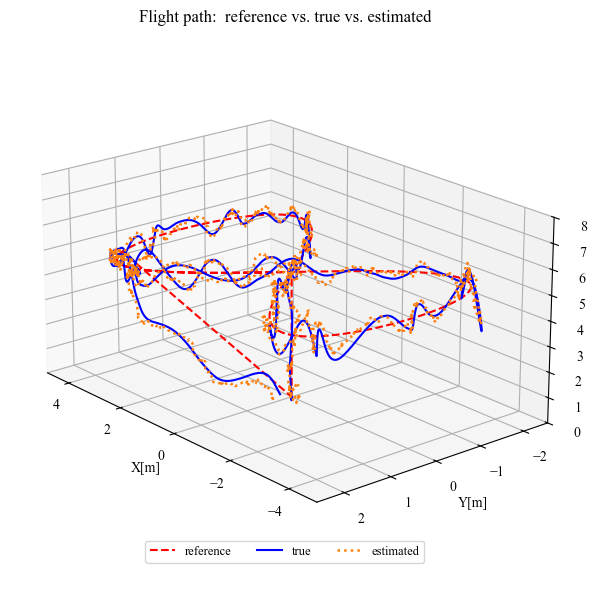

In [25]:
# The whole flight, viewed edge-on against the x-z plane.
fig = quad_ekf.plot_trajectory_3d(truth, est, config, azim=140)

The following figures take the estimate apart one channel at a time. **±2σ bands** the error curve above should stay inside the shaded $±2σ$ envelope most of the time ($≈95\%$). Escaping it often means the filter is over-confident; hugging zero far inside it means it is over-conservative.

- **Position** ($x,y,z$)

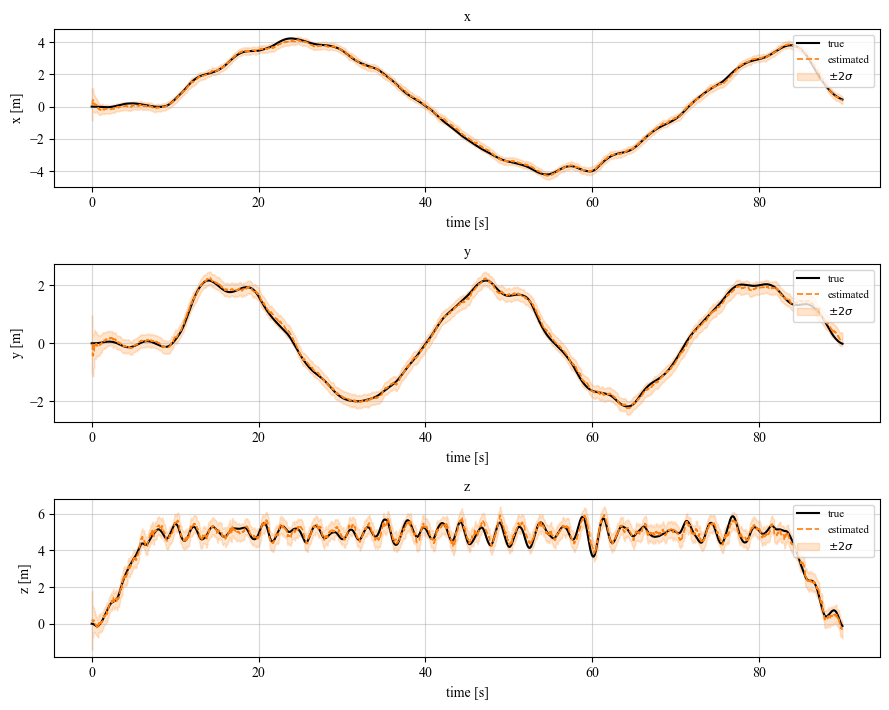

In [26]:
# Position channel: inertial coordinates vs. time, true vs. estimated (+-2 sigma).
quad_ekf.plot_estimation(truth, est, diag, states=('x', 'y', 'z'), show_nees=False);

Position ($x,y,z$): tracked to a few tens of centimetres - $GPS$ at $10 Hz$ bounds the position error while the dynamics bridges the gaps between fixes.


{{< pagebreak >}}

- **Velocity** ($v_x,v_y,v_z$)

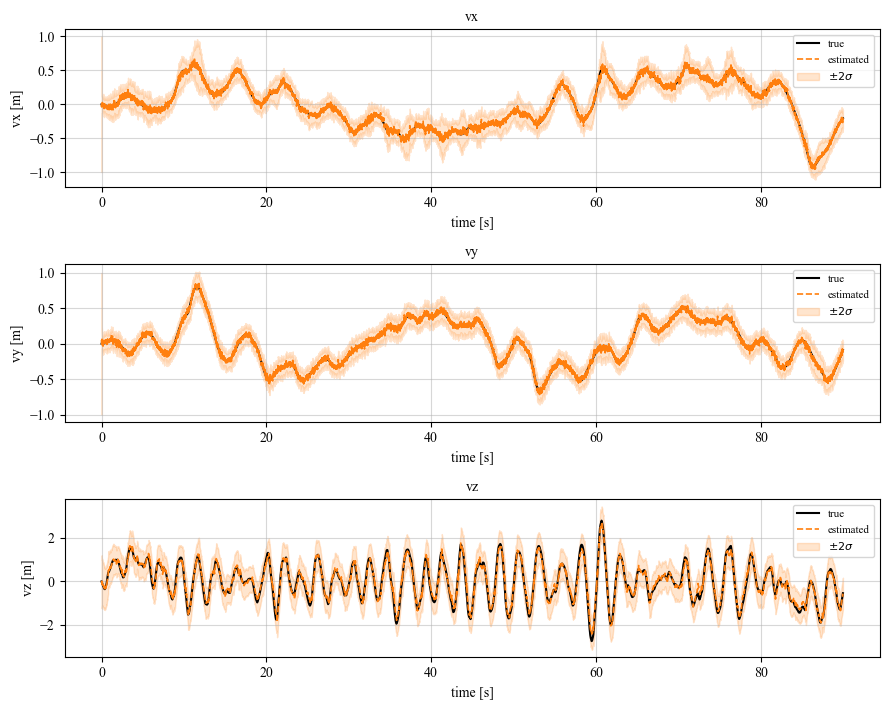

In [27]:
# Velocity channel — no direct velocity sensor; reconstructed by the filter.
quad_ekf.plot_estimation(truth, est, diag, states=('vx', 'vy', 'vz'), show_nees=False);

Velocity ($v_x,v_y,v_z$): thanks to the full specific-force accelerometer, horizontal velocity is typically estimated to a few centimetres/second even though there is no direct velocity sensor.

{{< pagebreak >}}

- **Attitude** ($\varphi,\theta,\psi$)

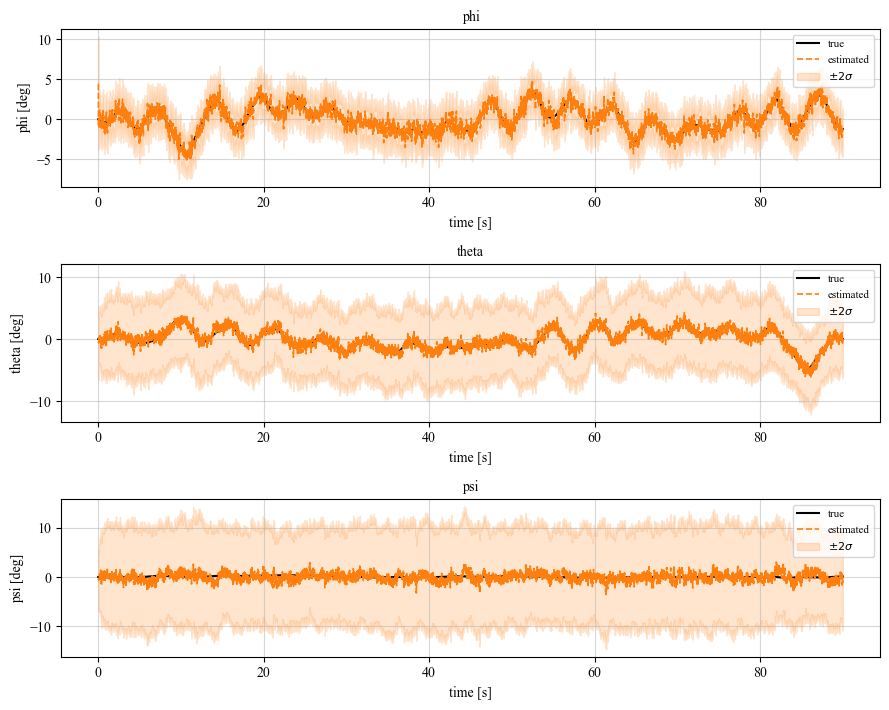

In [28]:
# Attitude channel: roll/pitch from the accelerometer, yaw from the magnetometer.
quad_ekf.plot_estimation(truth, est, diag, states=('phi', 'theta', 'psi'), show_nees=False);

Roll/pitch are observed by the accelerometer at $200 Hz$ and stay within a couple of degrees.  
Yaw relies on the $50 Hz$ magnetometer.

{{< pagebreak >}}

- **Errors** ($x, v_x, \varphi, \psi$)

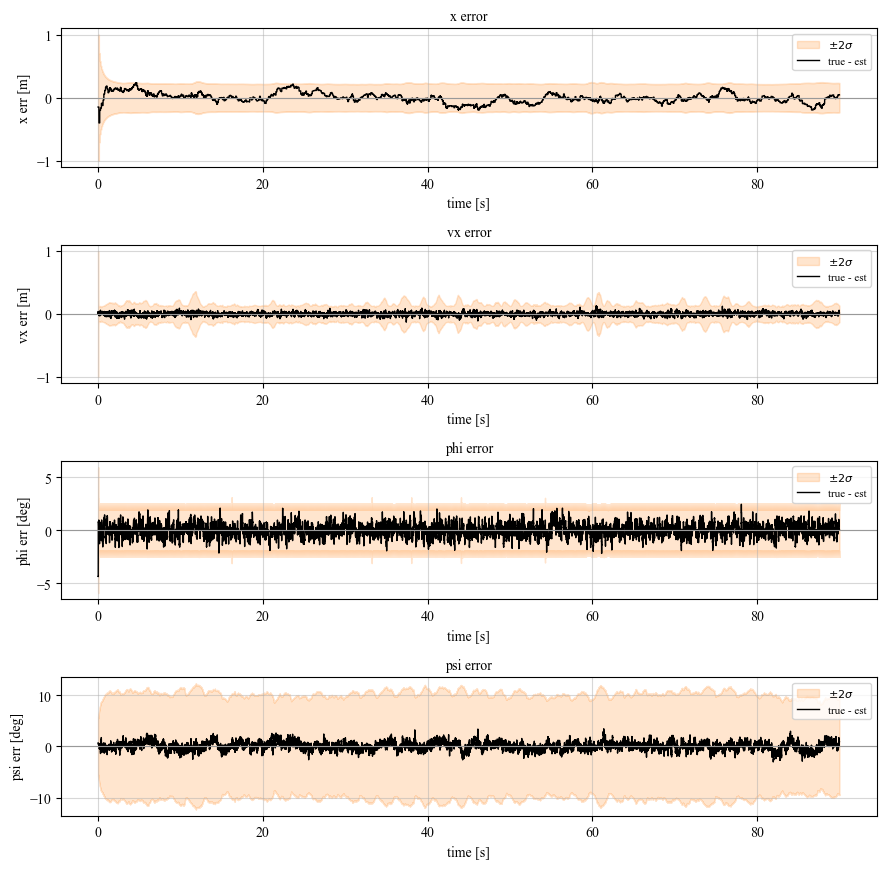

In [29]:
# Consistency: estimation error (true - est) against the filter's own +-2 sigma envelope.
quad_ekf.plot_error_bands(truth, est, diag, states=('x', 'vx', 'phi', 'psi'));

Each panel is the estimation error `true - est` for one state, against the $\pm 2\sigma$ envelope the filter reports for it.

- $x$ sits well inside its band: error RMS $\approx 0.07\,m$ against a $\approx\pm 0.22\,m$ envelope — about $0.6\sigma$. $GPS$ at $10\,Hz$ sets this uncertainty and the filter carries a little margin.
- $v_x$ stays well inside — $\approx 0.02\,m/s$ error in a $\approx\pm 0.14\,m/s$ band.
- $\varphi$ hugs zero: $\approx 0.6^\circ$ of error inside a $\approx\pm 6^\circ$ band. The $200\,Hz$ accelerometer pins roll far tighter than the covariance admits.
- $\psi$ error is $\approx 0.8^\circ$ inside a wide $\approx\pm 10^\circ$ band — the $50\,Hz$ 3-axis magnetometer keeps yaw honest, and with the vector update's inflated $R$ the filter reports generous uncertainty on it.

No channel escapes its band, so the filter is nowhere over-confident; every channel sits far enough inside that it reads as conservative. That slack is what the NEES quantifies next.

- **NEES** (Normalized Estimation Error Squared)

At each step the estimation error scaled by the filter's own claimed uncertainty,

$$
\varepsilon_k = \left(\mathbf x_k - \hat{\mathbf x}_k\right)^{\top} \mathbf P_k^{-1} \left(\mathbf x_k - \hat{\mathbf x}_k\right)
$$

That metric, known as the NEES is how big the error is, measured in units of the covariance $\mathbf P$ the filter reports.
It needs the true state, so it is a simulation-only diagnostic. For a consistent filter with an $n$-dimensional state ($n=12$ here) it averages to $n$:

- much above $n$ means the filter is over-confident (real errors larger than $\mathbf P$ admits)
- much below means over-conservative

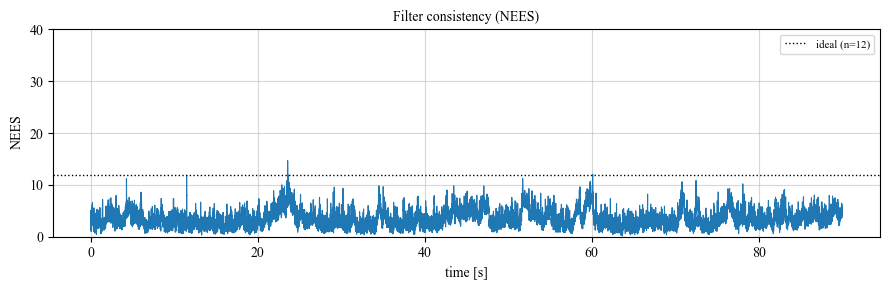

In [30]:
# Consistency: NEES vs. time (ideal ~ 12).
quad_ekf.plot_nees(diag);

NEES is *ideally* around $n=12$; 
with the accelerometer's dynamic term now properly modeled (rather than absorbed as noise), don't be surprised to see it run somewhat below $12$ - that means the filter is a little conservative (it reports more uncertainty than it turns out to need), which is a safer direction to be in than the reverse.

- **Metrics**

Two questions, two metrics, both restricted to the figure-8 phase:

1. **Estimation error** — how close is the $EKF$ estimate to the truth? Per-state RMSE (true vs. estimated), plus the mean NEES.
2. **Tracking error** — how well does the *controller* fly the reference figure-8 now that it closes the loop on that estimate rather than on truth? This is the very same `compute_metrics` the [Cascade-PID example](https://c4dynamics.github.io/c4dynamics/programs/pid_cascade/quadcopter_pid.html) reports (RMSE of the **true** path against the analytic reference), so the two runs line up directly and the difference is the cost of running on an estimate.

In [31]:
metrics = quad_ekf.compute_metrics(truth, est, diag)

state           RMSE   unit
---------------------------
x             0.0699   m
y             0.0652   m
z             0.1825   m
vx            0.0261   m/s
vy            0.0236   m/s
vz            0.1315   m/s
phi           0.0111   rad
theta         0.0101   rad
psi           0.0139   rad
p             0.0055   rad/s
q             0.0054   rad/s
r             0.0058   rad/s
---------------------------
NEES            3.28   (ideal ~ 12)


- **Control performance**

The estimator numbers above are the filter's own report card.  
But the controller never sees truth — it acts on that noisy estimate, so the figure-8 it actually flies is looser than the truth-fed run. 
Feeding the **true** trajectory back into `quad_pid.compute_metrics` scores that directly, against the same reference and the same figure-8 window as the parent notebook:

In [32]:
# Controller tracking performance -- the SAME metric as the Cascade-PID
# example (RMSE of the true path vs. the analytic figure-8 reference), only
# here the loop was closed on the EKF estimate instead of on truth.
from c4dynamics.controllers.quad_pid import compute_metrics as tracking_metrics

track = tracking_metrics(truth, trajectory)

print('=' * 50)
print('   TRACKING PERFORMANCE  (loop closed on estimate)')
print('=' * 50)
print(f'  RMSE x : {track["rmse_x"]:.4f} m   ({track["norm_x"]:.1f}% of x amplitude)')
print(f'  RMSE y : {track["rmse_y"]:.4f} m   ({track["norm_y"]:.1f}% of y amplitude)')
print(f'  RMSE z : {track["rmse_z"]:.4f} m   ({track["norm_z"]:.1f}% of altitude)')
print(f'  Max altitude deviation : {track["max_z_dev"]*100:.1f} cm')
print('=' * 50)

   TRACKING PERFORMANCE  (loop closed on estimate)
  RMSE x : 0.2151 m   (5.4% of x amplitude)
  RMSE y : 0.2100 m   (10.5% of y amplitude)
  RMSE z : 0.3599 m   (7.2% of altitude)
  Max altitude deviation : 134.4 cm


Compare with the loop closed on truth state samples: 

![cascade-PID (truth-fed) tracking performance](quad_ekf_truth_tracking.png)

Fed perfect state, the Cascade-PID example scored roughly $5\%$ / $9\%$ / $0.1\%$ RMSE on $x$ / $y$ / $z$. Closing the same loop on the $EKF$ estimate:

- **Horizontal** ($x, y$) barely moves — still $\approx 5\%$ / $10\%$ normalized RMSE. $GPS$ pins the absolute position at $10\,Hz$ and the estimate stays tight enough that the outer loop hardly notices it isn't truth.
- **Altitude** ($z$) is where estimation costs something real: RMSE grows from millimetres to $\approx 0.36\,m$ and the worst-case excursion from a few centimetres to $\approx 1.4\,m$. Unlike roll/pitch and horizontal velocity, the $z$ channel gets no accelerometer aiding — height rides on $10\,Hz$ $GPS$ alone (there is no barometer) — and the softened $K_{p_z}, K_{i_z}$ (Section $7$) further trade altitude stiffness for calm against that noise. This is the main price of output-feedback control in this example.

## 9. GPS Dropout Experiment

Section 2 raised a real question: this $EKF$ is always aided by $GPS$, so does $IMU$ rate start to matter once that aiding disappears?

When $GPS$ drops out the estimate has to get by on the physics model (propagated from the known motor commands) plus the $IMU$ and magnetometer corrections, with no absolute position fix until $GPS$ returns. This is **not** a strapdown INS falling back on pure inertial dead-reckoning — the model still does the propagating, the $IMU$ still only aids.

This section disables $GPS$ for a short window mid-flight — magnetometer and $IMU$ keep updating — and measures how far the position estimate drifts during that window, across several $IMU$ rates.

The control loop stays at a fixed $200\,Hz$ regardless of $IMU$ rate, and the accelerometer/gyro noise is rescaled with rate so a faster $IMU$ isn't an unrealistic free precision win. `jacobian_stride=4` keeps the sweep under two minutes.

In [33]:
# suppress ground hit warnings in the notebook; they are expected and not relevant to the EKF.
import warnings
import c4dynamics as c4d
warnings.simplefilter('ignore', c4d.c4warn)

# Same vehicle & gains as Section 8, a shorter flight so the sweep is fast,
# and GPS disabled for 1.5 s once the figure-8 is well underway.
trajectory_dropout = dict(trajectory, t_takeoff=1.5, t_land=1.5) #trajectory #
simulation_dropout = {'dt': 0.005, 'tf': 10.0} #simulation #
config_dropout = {
    'quad'      : quadcopter,
    'trajectory': trajectory_dropout,
    'controller': controller,
    'sim'       : simulation_dropout,
}
DROPOUT_WINDOW = (3.0, 4.5) #1.5 s, GPS off; IMU + magnetometer stay on
dropout_sweep = quad_ekf.run_gps_dropout_sweep(
    config_dropout, ekf_cfg,
    imu_rates_hz=(10, 50, 100, 150, 200),
    dropout_window=DROPOUT_WINDOW,
    n_trials=20,
    jacobian_stride=4,
)

IMU rate =     10 Hz  ->  RMS position error during 1.5s GPS dropout = 0.1986 m  (n=15/20)
IMU rate =     50 Hz  ->  RMS position error during 1.5s GPS dropout = 0.3026 m  (n=15/20)
IMU rate =    100 Hz  ->  RMS position error during 1.5s GPS dropout = 0.2631 m  (n=14/20)
IMU rate =    150 Hz  ->  RMS position error during 1.5s GPS dropout = 0.2717 m  (n=15/20)
IMU rate =    200 Hz  ->  RMS position error during 1.5s GPS dropout = 0.2719 m  (n=15/20)


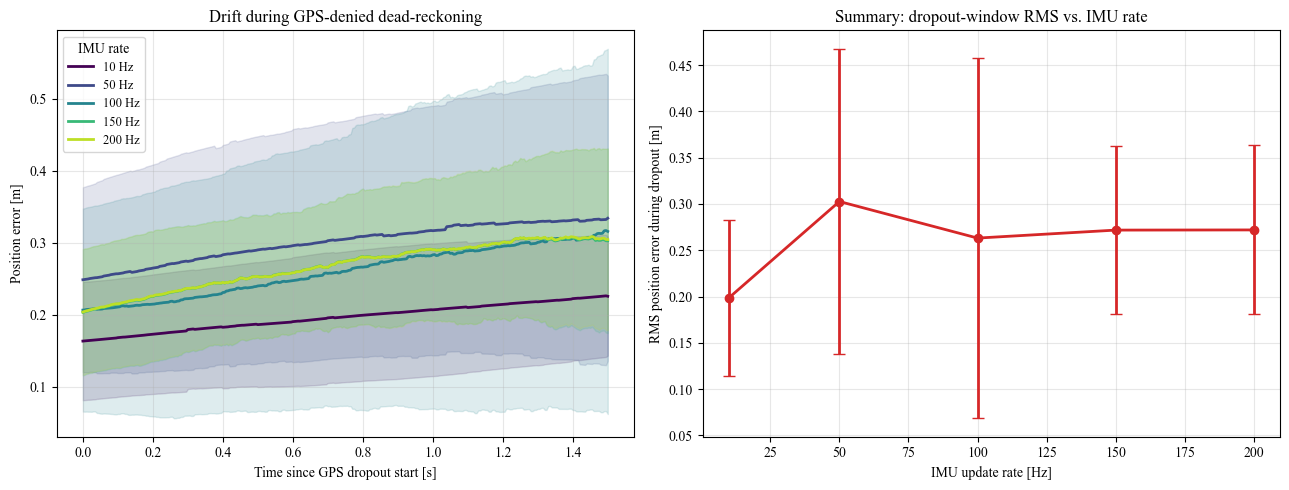

In [34]:
fig = quad_ekf.plot_gps_dropout(dropout_sweep)

**The reliable result** is the left panel: 
with $GPS$ gone, the position estimate slowly walks away from the truth and keeps walking until $GPS$ returns.  
Take away the only sensor that measures absolute position and the estimate drifts — plainly and measurably, in a way the always-aided run in Section $8$ never shows.

**Turning the IMU rate up did not slow that drift** — and that is what the Section $2$ comparison predicts. 
There are two ways a filter can use an $IMU$:

- *Strapdown* (what most aerospace systems do): the $IMU$ **is** the prediction. 
The estimate is carried forward in time by integrating the accelerometer and gyro directly, so sampling them twice as often means integrating on a finer grid and the dead-reckoned path is genuinely more accurate. 
Rate matters.
- *Model-based filter*: the estimate here is carried forward by the physics model, driven by the known motor commands (Section $5.1$). 
The $IMU$ is just one more correcting sensor, alongside $GPS$ and the magnetometer. 
It nudges the prediction; 
it never carries it.

**Why the extra nudges barely register.** 
A real $IMU$'s noise is a fixed amount *per second*, not per sample — take readings twice as fast and each one is about $\sqrt{2}$ noisier (see the noise-rescaling note above). 
So doubling the rate hands the filter twice as many readings that are each noisier, and the two effects cancel: 
two noisy half-looks tell you what one cleaner look would. 


On top of that, because the physics prediction is already good, the filter leans on the $IMU$ only lightly to begin with (a small Kalman gain) — small corrections, applied more often, on noisier data, land right back where they started.

So the flat sweep is the expected outcome. 
**IMU rate is a performance knob only when the IMU drives the prediction. Here it only aids it, so the rate does not move the needle**


## 10. Summary & Conclusions

The same figure-8 that the Cascade-$PID$ example flew on perfect state is now flown on a state **estimated** from realistic $GPS$ and $IMU$ — a complete estimation-control pipeline, built entirely on c4dynamics abstractions (`c4d.rigidbody`, `c4d.filters.ekf`, and the `sensors.navigation` models).

**Estimation.** $GPS$ at $10\,Hz$ bounds the absolute position while the dynamics model bridges the gaps between fixes: position tracks truth to $≈ 0.1\,m$ and horizontal velocity to a few $cm/s$ — with no velocity sensor at all. Roll and pitch, observed through the accelerometer's specific-force model at $200\,Hz$, hold to about half a degree; yaw, from the $50\,Hz$ 3-axis magnetometer, to $≈ 0.8°$. The filter runs conservative (mean $NEES ≈ 3$ against an ideal of $12$): it reports more uncertainty than it turns out to need, which is the safe direction to err.

**Control on the estimate.** Feeding that estimate to the cascade controller in place of truth costs almost nothing horizontally — figure-8 tracking $RMSE$ stays around $≈ 5\%/10\%$ of amplitude. Altitude is the exception: with no barometer and no accelerometer aiding on the $z$ channel, the hold degrades from millimetres to $≈ 0.35\,m$ $RMSE$, and the $z$ gains had to be softened (Section $7$) to keep the loop calm against the noisier signal.

**IMU rate.** Because this filter uses the $IMU$ to *correct* a model-based prediction rather than to *drive* it, its update rate is not a performance knob — raising it does not help the estimate ride out a $GPS$ dropout (Section $9$). A strapdown $INS$, where the $IMU$ rate *is* the prediction rate, would answer differently.

**Natural next steps** — small extensions to this example:

- **Sensor biases**: turn on the constant biases in the sensors and augment the state to estimate them online.
- **Barometer**: add a height measurement and recover the altitude-hold performance the Cascade-$PID$ example had.
- **GPS velocity**: add a lower-rate velocity measurement to tighten the velocity channel.
- **Waypoint / trajectory generation**: replace the analytic figure-8 with a planner.
- **Degraded sensing**: longer or repeated $GPS$ dropouts, inflated noise — watch the adaptive $R$ and the innovation gate respond.

**A larger follow-up**, rather than a tweak: build the strapdown-$INS$ counterpart — $IMU$ mechanization in the predict step, $GPS$ and magnetometer as the only aiding — and re-run the Section $9$ sweep. That is the experiment that turns Section $9$'s "would answer differently" into a demonstration, and it needs a richer $IMU$ error model (bias + random walk) to be worth doing.

# Appendix: Sensor Model Demonstrations

Section $4$ gave each sensor's error model and measurement equation on paper.  
This appendix runs the sensor objects on their own, outside the filter: each demo() drives its sensor with a known reference signal and plots the noisy, biased output against that ground truth — so the raw measurement behaviour the $EKF$'s update stage has to cope with is visible in isolation, before it's buried inside the closed loop.

In [35]:
from c4dynamics.sensors.navigation import imu, gps, magnetometer

## IMU

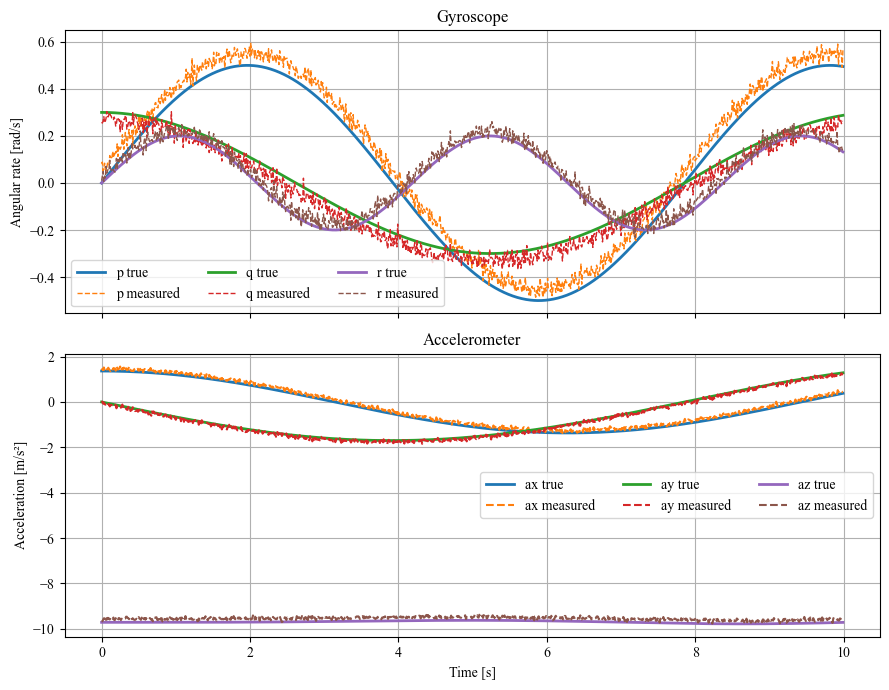

In [36]:
imu.demo();

## GPS

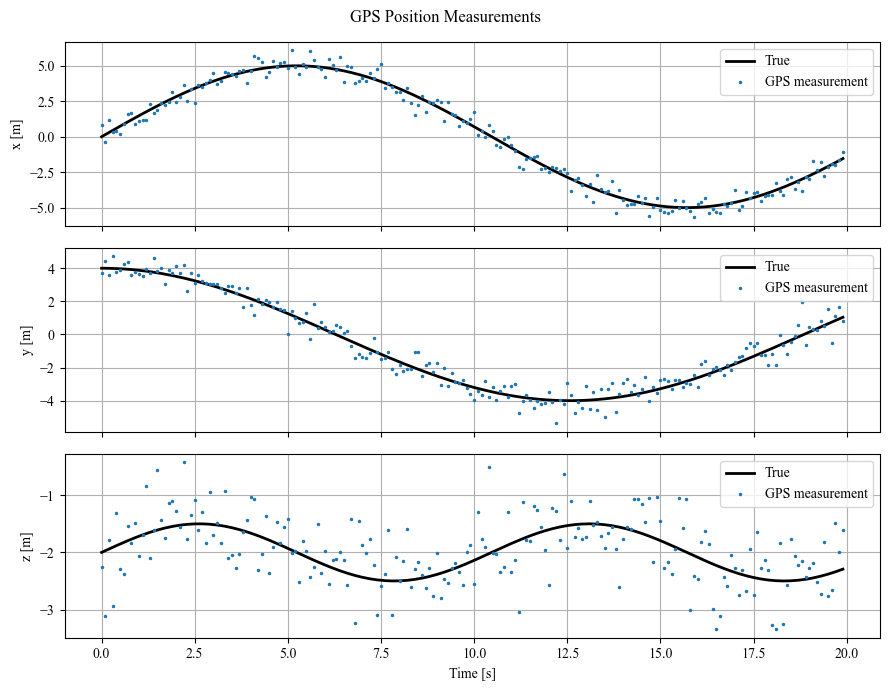

In [37]:
gps.demo();

## Magnetometer 

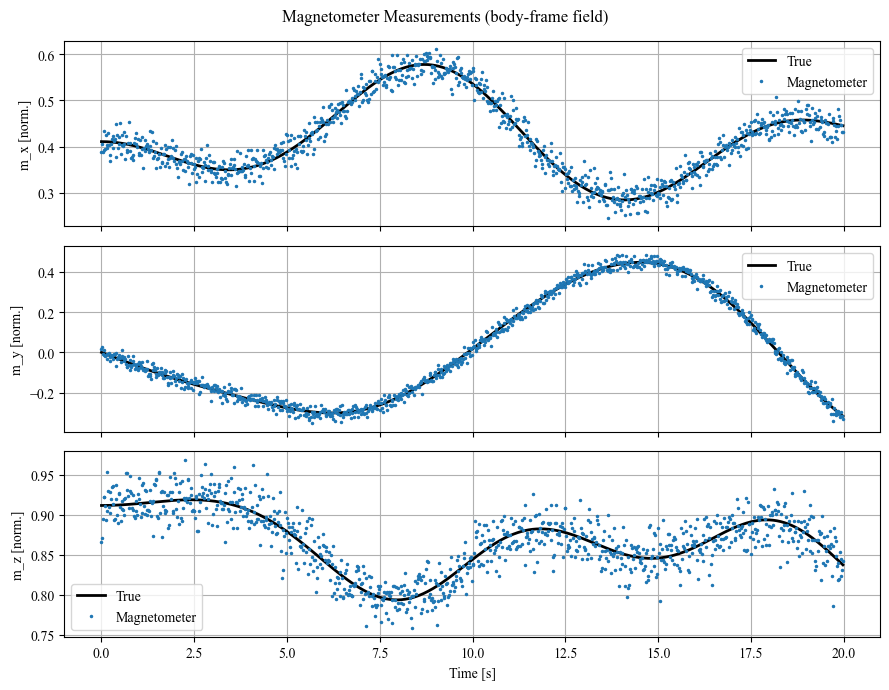

In [38]:
magnetometer.demo();